In [51]:
import pandas as pd 
import matplotlib.pyplot as plt
# from sqlalchemy import create_engine
# import os


In [2]:
df=pd.read_csv('DA_task_dataset.csv')

In [3]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62.0,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               7
Neighbourhood     7
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Neighbourhood']=df['Neighbourhood'].fillna('Unknown')

In [7]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [8]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.089109,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.109677,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.920000e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [ ]:
df['Gender'] = df['Gender'].str.strip().str.lower()

In [21]:
gender_mapping = {
    'm': 'Male',
    'male': 'Male',
    'mal': 'Male',
    'ml': 'Male',

    'f': 'Female',
    'fe': 'Female',
    'female': 'Female',
    'femal': 'Female',
    'fml': 'Female',

    'o': 'Other',
    'other': 'Other',
    'othr': 'Other'
}

In [22]:
df['Gender'] = df['Gender'].replace(gender_mapping)

In [23]:
print(df['Gender'].unique())

['Female' 'Male' 'Other']


In [24]:
print(df['Neighbourhood'].unique())

['JARDIM DA PENHA' 'MATA DA PRAIA' 'PONTAL DE CAMBURI' 'REPÚBLICA'
 'GOIABEIRAS' 'ANDORINHAS' 'CONQUISTA' 'NOVA PALESTINA' 'DA PENHA'
 'TABUAZEIRO' 'BENTO FERREIRA' 'SÃO PEDRO' 'SANTA MARTHA' 'SÃO CRISTÓVÃO'
 'MARUÍPE' 'GRANDE VITÓRIA' 'SÃO BENEDITO' 'ILHA DAS CAIEIRAS'
 'SANTO ANDRÉ' 'SOLON BORGES' 'BONFIM' 'JARDIM CAMBURI' 'MARIA ORTIZ'
 'JABOUR' 'ANTÔNIO HONÓRIO' 'RESISTÊNCIA' 'ILHA DE SANTA MARIA'
 'JUCUTUQUARA' 'MONTE BELO' 'MÁRIO CYPRESTE' 'SANTO ANTÔNIO' 'BELA VISTA'
 'PRAIA DO SUÁ' 'SANTA HELENA' 'ITARARÉ' 'INHANGUETÁ' 'UNIVERSITÁRIO'
 'SÃO JOSÉ' 'REDENÇÃO' 'SANTA CLARA' 'CENTRO' 'PARQUE MOSCOSO'
 'DO MOSCOSO' 'SANTOS DUMONT' 'CARATOÍRA' 'ARIOVALDO FAVALESSA'
 'ILHA DO FRADE' 'GURIGICA' 'JOANA D´ARC' 'CONSOLAÇÃO' 'PRAIA DO CANTO'
 'BOA VISTA' 'MORADA DE CAMBURI' 'SANTA LUÍZA' 'SANTA LÚCIA'
 'BARRO VERMELHO' 'ESTRELINHA' 'FORTE SÃO JOÃO' 'FONTE GRANDE'
 'ENSEADA DO SUÁ' 'SANTOS REIS' 'PIEDADE' 'JESUS DE NAZARETH'
 'SANTA TEREZA' 'CRUZAMENTO' 'ILHA DO PRÍNCIPE' 'ROMÃO' 'COMDUSA'


In [28]:
df['No-show'].unique()

array(['No', 'Yes'], dtype=object)

In [29]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: PatientId
[2.98724998e+13 5.58997777e+14 4.26296230e+12 ... 7.26331493e+13
 9.96997666e+14 1.55766317e+13]

Column: AppointmentID
[5642903 5642503 5642549 ... 5630692 5630323 5629448]

Column: Gender
['Female' 'Male' 'Other']

Column: ScheduledDay
['2016-04-29T18:38:08Z' '2016-04-29T16:08:27Z' '2016-04-29T16:19:04Z' ...
 '2016-04-27T16:03:52Z' '2016-04-27T15:09:23Z' '2016-04-27T13:30:56Z']

Column: AppointmentDay
['2016-04-29T00:00:00Z' '2016-05-03T00:00:00Z' '2016-05-10T00:00:00Z'
 '2016-05-17T00:00:00Z' '2016-05-24T00:00:00Z' '2016-05-31T00:00:00Z'
 '2016-05-02T00:00:00Z' '2016-05-30T00:00:00Z' '2016-05-16T00:00:00Z'
 '2016-05-04T00:00:00Z' '2016-05-19T00:00:00Z' '2016-05-12T00:00:00Z'
 '2016-05-06T00:00:00Z' '2016-05-20T00:00:00Z' '2016-05-05T00:00:00Z'
 '2016-05-13T00:00:00Z' '2016-05-09T00:00:00Z' '2016-05-25T00:00:00Z'
 '2016-05-11T00:00:00Z' '2016-05-18T00:00:00Z' '2016-05-14T00:00:00Z'
 '2016-06-02T00:00:00Z' '2016-06-03T00:00:00Z' '2016-06-06T00:00:00Z'
 '2016-06-07T0

In [31]:
df = df[df['Age'] >= 1]

In [52]:
total_records = len(df)
print("Total Records:", total_records)

Total Records: 69828


In [53]:
status_split = df['No-show'].value_counts()
print(status_split)

No-show
No     49894
Yes    19934
Name: count, dtype: int64


In [54]:
status_split.rename({
    'No': 'Showed Up',
    'Yes': 'No-show'
}, inplace=True)

print(status_split)


No-show
Showed Up    49894
No-show      19934
Name: count, dtype: int64


In [55]:
status_percentage = (df['No-show'].value_counts(normalize=True) * 100).round(2)

print(status_percentage)

No-show
No     71.45
Yes    28.55
Name: proportion, dtype: float64


In [56]:
neighbourhood_counts = df['Neighbourhood'].value_counts()

print(neighbourhood_counts.head(10))

Neighbourhood
JARDIM CAMBURI       5129
MARIA ORTIZ          3579
RESISTÊNCIA          2687
JARDIM DA PENHA      2638
ITARARÉ              2315
CENTRO               2237
TABUAZEIRO           1865
JESUS DE NAZARETH    1683
BONFIM               1672
CARATOÍRA            1658
Name: count, dtype: int64


In [57]:
noshow_by_neighbourhood = (
    df.groupby('Neighbourhood')['No-show']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(noshow_by_neighbourhood.head(10))

Neighbourhood
ILHAS OCEÂNICAS DE TRINDADE    100.000000
GURIGICA                        38.379942
JESUS DE NAZARETH               38.027332
ITARARÉ                         36.544276
HORTO                           35.185185
SANTOS DUMONT                   35.040745
SANTA CLARA                     33.776596
ARIOVALDO FAVALESSA             33.532934
SANTA CECÍLIA                   33.043478
ILHA DO PRÍNCIPE                32.501686
Name: No-show, dtype: float64


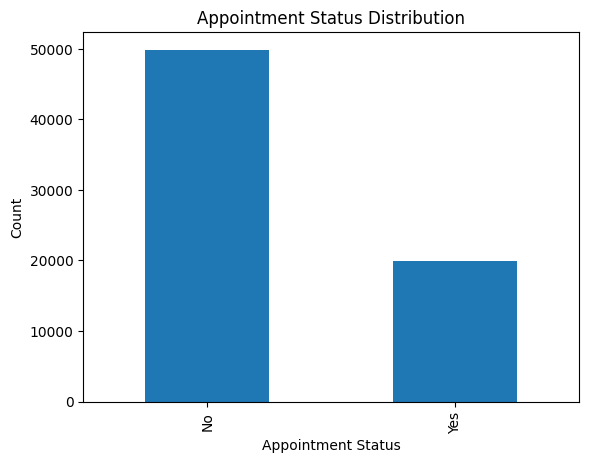

In [58]:

import matplotlib.pyplot as plt

df['No-show'].value_counts().plot(kind='bar')

plt.title('Appointment Status Distribution')
plt.xlabel('Appointment Status')
plt.ylabel('Count')

plt.show()

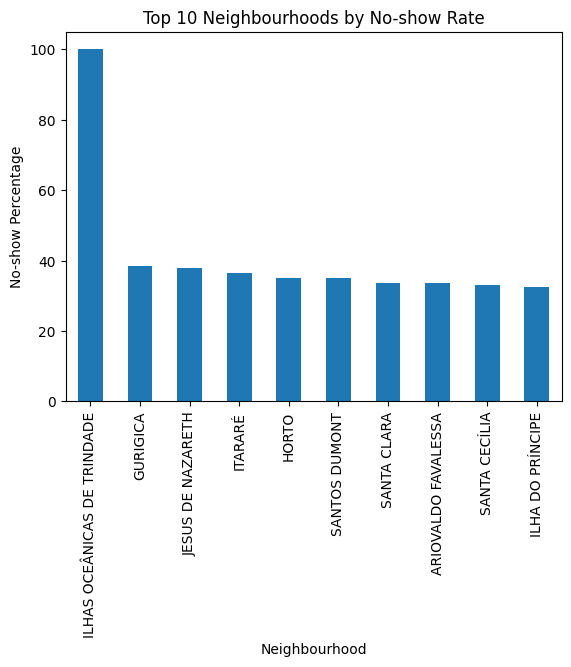

In [59]:
top_noshow = noshow_by_neighbourhood.head(10)

top_noshow.plot(kind='bar')

plt.title('Top 10 Neighbourhoods by No-show Rate')
plt.xlabel('Neighbourhood')
plt.ylabel('No-show Percentage')

plt.show()

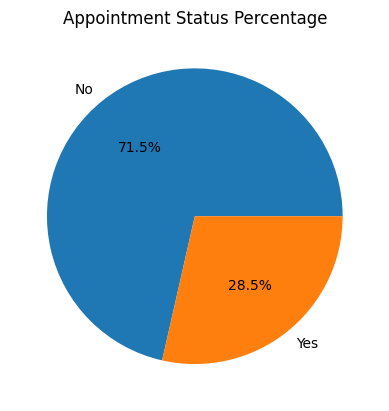

In [60]:
df['No-show'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Appointment Status Percentage')
plt.ylabel('')

plt.show()

# No-Show Trend By Gender

In [63]:
gender_noshow = pd.crosstab(
    df['Gender'],
    df['No-show'],
    normalize='index'
) * 100

print(gender_noshow)

No-show          No        Yes
Gender                        
Female    71.549469  28.450531
Male      71.245558  28.754442
Other    100.000000   0.000000


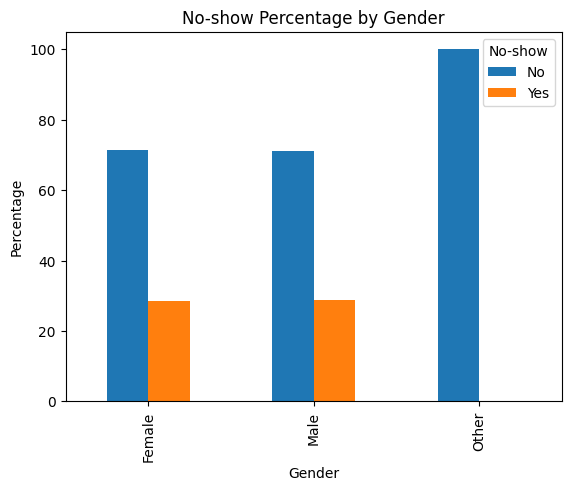

In [64]:
gender_noshow.plot(kind='bar')

plt.title('No-show Percentage by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage')

plt.show()

In [65]:
bins = [0, 18, 35, 60, 120]
labels = ['Child', 'Young Adult', 'Adult', 'Senior']

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [66]:
age_analysis = pd.crosstab(
    df['Age_Group'],
    df['No-show'],
    normalize='index'
) * 100

print(age_analysis)

No-show             No        Yes
Age_Group                        
Child        66.791921  33.208079
Young Adult  65.779080  34.220920
Adult        73.285270  26.714730
Senior       79.543485  20.456515


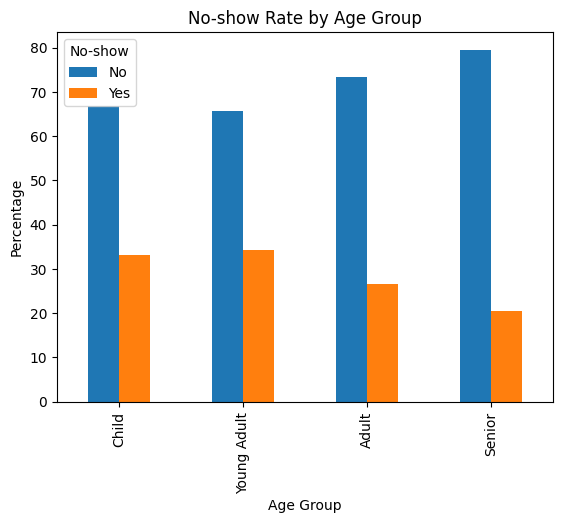

In [67]:
age_analysis.plot(kind='bar')

plt.title('No-show Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage')

plt.show()

# No-Show Trend by Waiting Period

In [68]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

df['Waiting_Days'] = (
    df['AppointmentDay'] - df['ScheduledDay']
).dt.days

In [69]:
df = df[df['Waiting_Days'] >= 0]

In [70]:
waiting_analysis = df.groupby('No-show')['Waiting_Days'].mean()

print(waiting_analysis)

No-show
No     13.939572
Yes    16.172770
Name: Waiting_Days, dtype: float64


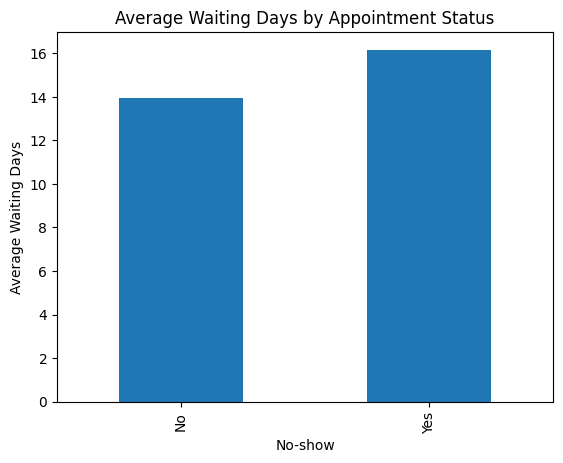

In [71]:
waiting_analysis.plot(kind='bar')

plt.title('Average Waiting Days by Appointment Status')
plt.xlabel('No-show')
plt.ylabel('Average Waiting Days')

plt.show()

# No-Show Trend based Diabetes Patient

In [72]:
diabetes_analysis = pd.crosstab(
    df['Diabetes'],
    df['No-show'],
    normalize='index'
) * 100

print(diabetes_analysis)

No-show          No        Yes
Diabetes                      
0         71.153279  28.846721
1         75.041845  24.958155


# No-Show Trend based on SMS 

In [73]:
sms_analysis = pd.crosstab(
    df['SMS_received'],
    df['No-show'],
    normalize='index'
) * 100

print(sms_analysis.round(2))

No-show          No    Yes
SMS_received              
0             70.59  29.41
1             72.33  27.67


In [74]:
sms_analysis.index = ['No SMS', 'Received SMS']

sms_analysis.columns = ['Showed Up', 'No-show']

print(sms_analysis.round(2))

              Showed Up  No-show
No SMS            70.59    29.41
Received SMS      72.33    27.67


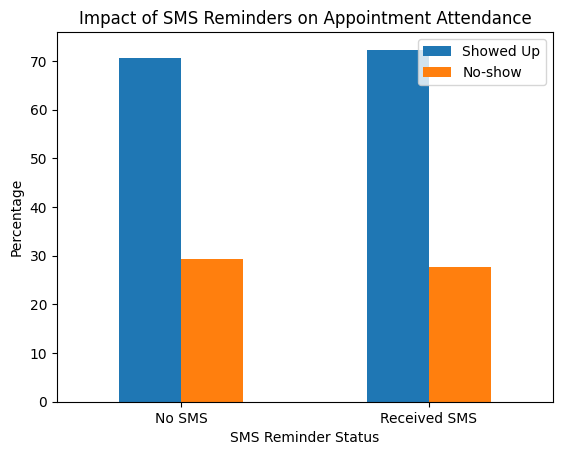

In [75]:
sms_analysis.plot(kind='bar')

plt.title('Impact of SMS Reminders on Appointment Attendance')
plt.xlabel('SMS Reminder Status')
plt.ylabel('Percentage')

plt.xticks(rotation=0)

plt.show()

# No-Show Trend based Waiting Category Bucket

In [76]:
bins = [-1, 0, 7, 30, 1000]

labels = ['Same Day', '1-7 Days', '8-30 Days', '30+ Days']

df['Waiting_Category'] = pd.cut(
    df['Waiting_Days'],
    bins=bins,
    labels=labels
)

In [77]:
waiting_category_analysis = pd.crosstab(
    df['Waiting_Category'],
    df['No-show'],
    normalize='index'
) * 100

print(waiting_category_analysis.round(2))

No-show              No    Yes
Waiting_Category              
Same Day          78.62  21.38
1-7 Days          75.03  24.97
8-30 Days         67.89  32.11
30+ Days          66.85  33.15


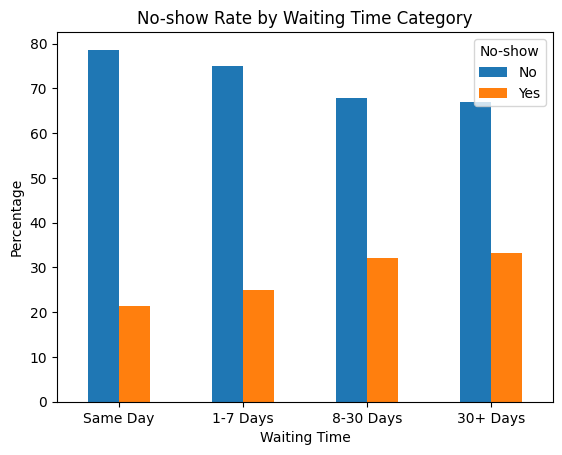

In [78]:
waiting_category_analysis.plot(kind='bar')

plt.title('No-show Rate by Waiting Time Category')
plt.xlabel('Waiting Time')
plt.ylabel('Percentage')

plt.xticks(rotation=0)

plt.show()

In [79]:
columns = [
    'Scholarship',
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap'
]

for col in columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Scholarship
Scholarship
0    63184
1     6644
Name: count, dtype: int64

Hipertension
Hipertension
0    54796
1    15032
Name: count, dtype: int64

Diabetes
Diabetes
0    64451
1     5377
Name: count, dtype: int64

Alcoholism
Alcoholism
0    68006
1     1822
Name: count, dtype: int64

Handcap
Handcap
0    68521
1     1185
2      112
3        8
4        2
Name: count, dtype: int64


In [80]:
for col in columns:
    
    percentage = (
        df[col]
        .value_counts(normalize=True) * 100
    ).round(2)
    
    percentage = percentage.rename({
        0: 'No',
        1: 'Yes'
    })
    
    print(f"\n{col}")
    print(percentage)


Scholarship
Scholarship
No     90.49
Yes     9.51
Name: proportion, dtype: float64

Hipertension
Hipertension
No     78.47
Yes    21.53
Name: proportion, dtype: float64

Diabetes
Diabetes
No     92.3
Yes     7.7
Name: proportion, dtype: float64

Alcoholism
Alcoholism
No     97.39
Yes     2.61
Name: proportion, dtype: float64

Handcap
Handcap
No     98.13
Yes     1.70
2       0.16
3       0.01
4       0.00
Name: proportion, dtype: float64
